# Global TC Tracks

Plots every storm's track that passes the same filtering used across other figures. 

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

from ike_climatology import config
from ike_climatology.ibtracs_io import load_storm_tracks
from ike_climatology.ibtracs_preprocessing import MIN_VMAX_KTS
from ike_climatology.style import BASIN_COLORS, DESIRED_BASIN_ORDER


## Data extraction

`load_storm_tracks` mirrors `load_master_dataframe`'s default filtering
(`apply_quality_filters=True`), but tracks *why* each rejected storm was excluded
(crossover / below-intensity / no valid IKE / other) rather than just pass/fail.

In [3]:
tracks_df, rejection_counts = load_storm_tracks(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if tracks_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")

total_storms = len(tracks_df)
storms_per_basin = tracks_df["basin"].value_counts().to_dict()


--- Plotting Global TC Tracks (2004-2024) ---
  Processing North Atlantic...
    Plotted 340 storms  (rejected: 2 crossover, 24 below-intensity, 13 no valid IKE, 1 other)
  Processing East Pacific...
    Plotted 366 storms  (rejected: 76 crossover, 52 below-intensity, 1 no valid IKE, 2 other)
  Processing West Pacific...
    Plotted 452 storms  (rejected: 14 crossover, 106 below-intensity, 50 no valid IKE, 0 other)
  Processing North Indian...
    Plotted 97 storms  (rejected: 11 crossover, 85 below-intensity, 18 no valid IKE, 9 other)
  Processing South Indian...
    Plotted 290 storms  (rejected: 18 crossover, 33 below-intensity, 26 no valid IKE, 0 other)
  Processing South Pacific...
    Plotted 163 storms  (rejected: 9 crossover, 18 below-intensity, 20 no valid IKE, 0 other)

  Total storms plotted: 1,708


## Summary

Per-basin storm counts and the global rejection breakdown -- useful for a methods-
section sentence like "n = X storms met the inclusion criteria."

In [4]:
totals = {"crossover": 0, "below_intensity": 0, "no_ike": 0, "other": 0}
for basin_counts in rejection_counts.values():
    for key in totals:
        totals[key] += basin_counts[key]

print(f"Total storms plotted: {total_storms:,}")
print("\nPer-basin breakdown:")
for basin in DESIRED_BASIN_ORDER:
    print(f"  {basin:18s}: {storms_per_basin.get(basin, 0):4d} storms")
print("\nGlobal rejection breakdown:")
print(f"  Crossover (wrong genesis basin):  {totals['crossover']:4d}")
print(f"  Below intensity (Vmax<{MIN_VMAX_KTS}kt):    {totals['below_intensity']:4d}")
print(f"  No valid IKE (no R34 reported):   {totals['no_ike']:4d}")
print(f"  Other (missing/invalid):          {totals['other']:4d}")


Total storms plotted: 1,708

Per-basin breakdown:
  North Atlantic    :  340 storms
  East Pacific      :  366 storms
  West Pacific      :  452 storms
  North Indian      :   97 storms
  South Indian      :  290 storms
  South Pacific     :  163 storms

Global rejection breakdown:
  Crossover (wrong genesis basin):   130
  Below intensity (Vmax<34kt):     318
  No valid IKE (no R34 reported):    128
  Other (missing/invalid):            12


## Figure: global TC tracks

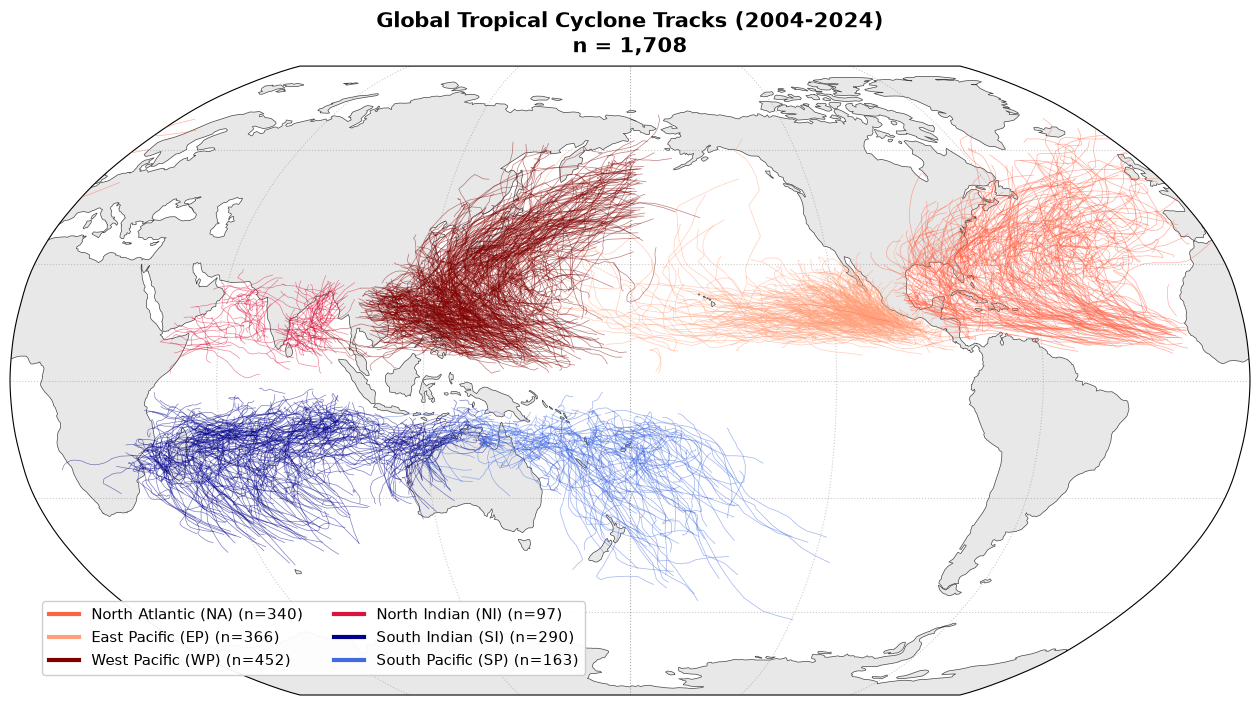


Figure saved to: /home/sydney.e.walters/IBTrACS_Manuscript_Figures/global_tc_tracks_2004_2024.png


In [5]:
fig = plt.figure(figsize=(16, 9))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#e8e8e8", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#444", zorder=2)
ax.gridlines(draw_labels=False, linestyle=":", alpha=0.4, color="gray", zorder=0)

for basin, storm_group in tracks_df.groupby("basin"):
    color = BASIN_COLORS.get(basin, "gray")
    for _, row in storm_group.iterrows():
        ax.plot(            row["lons"], row["lats"],
            color=color, linewidth=0.5, alpha=0.5,
            transform=ccrs.PlateCarree(), zorder=3,
        )

ax.set_title(
    f"Global Tropical Cyclone Tracks ({config.START_YEAR}-{config.END_YEAR})\n"
    f"n = {total_storms:,}",
    fontsize=15, fontweight="bold", pad=10,
)

legend_handles = [
    Line2D([0], [0], color=BASIN_COLORS[basin], lw=3,
           label=f"{basin} ({config.IBTRACS_BASIN_CODES[basin]}) "
                 f"(n={storms_per_basin.get(basin, 0)})")
    for basin in DESIRED_BASIN_ORDER
]

ax.legend(
    handles=legend_handles, loc="lower left", bbox_to_anchor=(0.02, 0.02),
    fontsize=11, frameon=True, framealpha=0.95, ncol=2,
)

os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
output_path = os.path.join(config.BASE_OUTPUT_DIR, "global_tc_tracks_2004_2024.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nFigure saved to: {output_path}")
